# Exploratory Data Analysis

In [1]:
# Standard library imports
import os
import json

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
import cv2
import matplotlib.image as mpimg  # For loading images

In [2]:
def create_dummy_image():
    dummy_image_path = "nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255

In [3]:
# Define the directory containing the labeled dataset
directory = r'C:\Users\david\Desktop\project\dataset\Labeled'

# Initialize an empty list to store data
data = []

# Iterate through all files in the directory
for file in os.listdir(directory):
    if file.lower().endswith('.jpg'):
        image_path = os.path.join(directory, file)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

df = pd.DataFrame(data)
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB
None


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


# EDA

In [4]:
df.label.value_counts()

label
good           162
no_good        116
exc_solder      81
spike           38
poor_solder     31
Name: count, dtype: int64

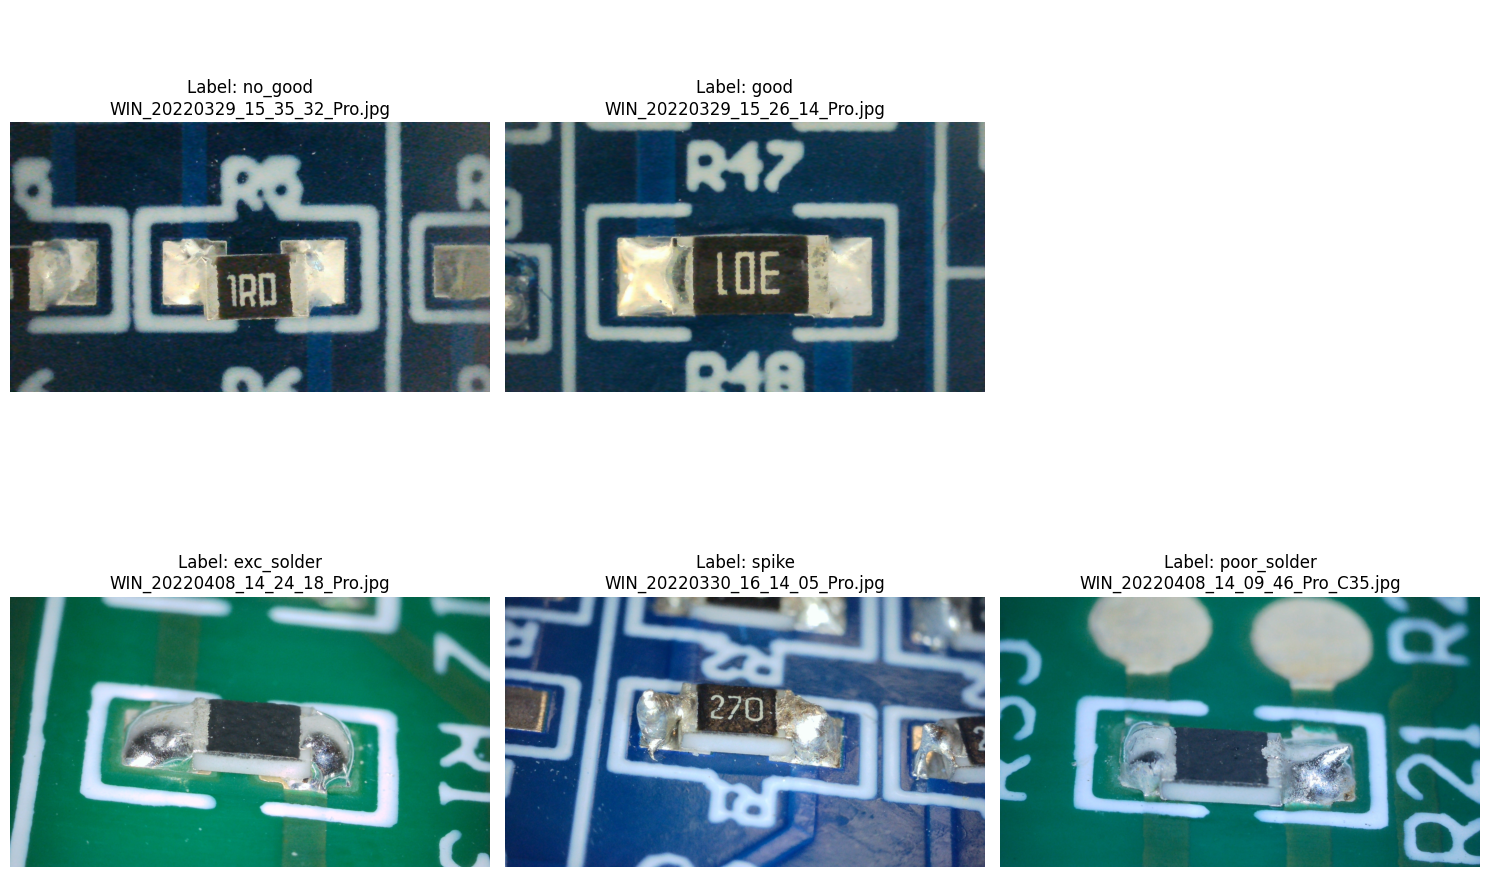

In [5]:
# Define subplot mapping for labels
subplot_mapping = {
    "no_good": (0, 0),
    "good": (0, 1),
    "exc_solder": (1, 0),
    "spike": (1, 1),
    "poor_solder": (1, 2)
}

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Iterate through each label and its subplot position
for label, (row, col) in subplot_mapping.items():
    ax = axes[row, col]
    group = df[df['label'] == label]
    
    if not group.empty:
        # Sample one image from the group
        sample = group.sample(n=1).iloc[0]
        image_path = sample['filename']
        
        try:
            # Load and display the image
            image = Image.open(image_path)
            ax.imshow(image)
        except Exception as e:
            # Display error message if image loading fails
            ax.text(0.5, 0.5, f"Error loading image:\n{e}", ha='center', va='center')
    else:
        # Display message if no image is found for the label
        ax.text(0.5, 0.5, "No image found", ha='center', va='center')
    
    # Set title and turn off axis
    ax.set_title(f"Label: {label}\n{os.path.basename(sample['filename']) if not group.empty else ''}")
    ax.axis('off')

# Turn off unused subplot axes if there are fewer than 6 unique labels
used_positions = set(subplot_mapping.values())
for r in range(2):
    for c in range(3):
        if (r, c) not in used_positions:
            axes[r, c].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# preprocessing and augmentation

In [6]:
# Preprocessing
df_filtered = df[~df['label'].isin(['good', 'no_good'])].copy()